# Custom Transformer

In [1]:
import pandas as pd
import seaborn as sns

👉 We will use this dataset:

In [2]:
data = pd.read_csv("https://d32aokrjazspmn.cloudfront.net/materials/custom_transformer_data.csv")
data.head()

,customer_state,seller_state,product_weight_g,product_length_cm,product_height_cm,product_width_cm,days_until_delivery
0,RJ,SP,1825,53,10,40,9
1,RJ,SP,700,65,18,28,9
2,RJ,SP,1825,53,10,40,11
3,RJ,SP,1825,53,10,40,12
4,RJ,SP,1825,53,10,40,14


- Each observation in the dataset represents a product being delivered from a `seller_state` to a `customer_state`.
- The other columns describe the packaging characteristics of each product.

🎯 The target is the number of days between the order and the delivery.

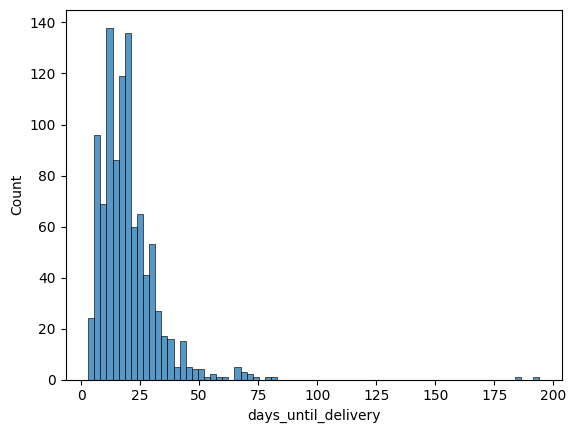

In [3]:
#  Check the target
sns.histplot(data.days_until_delivery);

## 1. Pipeline

👉 Create a scikit-learn pipeline called `pipe`:

- Derive a `volume` feature from the dimensions features (`dimensions`)
- Keep the original product dimension features for training
- Scale all numerical features
- Encode categorical features
- Add a `Ridge` regression estimator with default settings

**Note:** The holdout method will be ignored for this challenge; you do not need to use `train_test_split`!

<details><summary><strong>Hints</strong></summary>

- There are many ways to build your preprocessed feature matrix (using `ColumnTransformer` and/or `FeatureUnion`).
    
- If your transformed feature matrix looks strange, it may be because `OneHotEncoder(sparse_output=True)` stores the matrix as "sparse" by default. Use `.todense()` to convert it back to a dense matrix.

- To get a Pandas DataFrame output with column names instead of the default NumPy array output, use `.set_output(transform='pandas')` on your final pipeline. (You do not need to set this on each transformer individually — setting it on the pipeline propagates it to sub-steps.)

</details>

<br>

<details><summary><strong>More hints: step-by-step guidance</strong> (only open if you are stuck)</summary>

Here is the easiest way to build the pipeline.

1. Create a Python `function` that computes the volume given length, width, and height.
2. Build a volume calculator pipeline consisting of:
   1. A `FunctionTransformer` that uses your Python `function`.
   1. Followed by a scaler.
3. Build a full preprocessor using `ColumnTransformer`:
   - A scaler for the original numerical features.
   - An encoder for the categorical features.
   - Your volume calculator pipeline for the length, width, and height features.
4. Finally, build a pipeline containing your full preprocessor followed by the `Ridge` model.

</details>

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.compose import make_column_selector

from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

from sklearn.base import TransformerMixin
from sklearn.base import BaseEstimator

from sklearn.pipeline import FeatureUnion

from sklearn.linear_model import Ridge

In [5]:
X = data.drop(columns=['days_until_delivery'])
y = data['days_until_delivery']
X.head()

,customer_state,seller_state,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,RJ,SP,1825,53,10,40
1,RJ,SP,700,65,18,28
2,RJ,SP,1825,53,10,40
3,RJ,SP,1825,53,10,40
4,RJ,SP,1825,53,10,40


In [6]:
def multiply(df):
    return pd.DataFrame(
        df["product_length_cm"] * df["product_height_cm"] * df["product_width_cm"]
    )

volume_computer = Pipeline(
    [
        ("compute_volume", FunctionTransformer(multiply)),
        ("scale_volume", MinMaxScaler()),
    ]
)

final_preprocessor = ColumnTransformer(
    [
        ("num_scaler", MinMaxScaler(), make_column_selector(dtype_include="int64")),

        ("cat_encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="if_binary"), make_column_selector(dtype_include="object")),

        ("volume_computer", volume_computer, ["product_length_cm", "product_height_cm", "product_width_cm"]),
    ]
).set_output(transform="pandas")

final_preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_scaler', ...), ('cat_encoder', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``fe

In [9]:
final_preprocessor.fit_transform(X)

,num_scaler__product_weight_g,num_scaler__product_length_cm,num_scaler__product_height_cm,num_scaler__product_width_cm,cat_encoder__customer_state_AL,cat_encoder__customer_state_AM,cat_encoder__customer_state_AP,cat_encoder__customer_state_BA,cat_encoder__customer_state_CE,cat_encoder__customer_state_DF,...,cat_encoder__customer_state_RJ,cat_encoder__customer_state_RN,cat_encoder__customer_state_RO,cat_encoder__customer_state_RS,cat_encoder__customer_state_SC,cat_encoder__customer_state_SE,cat_encoder__customer_state_SP,cat_encoder__customer_state_TO,cat_encoder__seller_state_SP,volume_computer__x0
0,0.057692,0.402439,0.056818,0.271028,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.079177
1,0.020067,0.548780,0.147727,0.158879,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.125218
2,0.057692,0.402439,0.056818,0.271028,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.079177
3,0.057692,0.402439,0.056818,0.271028,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.079177
4,0.057692,0.402439,0.056818,0.271028,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.079177
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.558528,0.524390,0.602273,0.121495,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.344015
996,0.019231,0.243902,0.147727,0.224299,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.095108
997,0.065217,0.304878,0.113636,0.224299,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.088836
998,0.289298,0.390244,0.522727,0.056075,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.174302


In [10]:
X.shape

(1000, 6)

In [12]:
pipe = Pipeline([
    ('preprocessing', final_preprocessor),
    ('linear_regression', Ridge())
])

pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('linear_regression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_scaler', ...), ('cat_encoder', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output

#### 🧪  Test your pipe

In [13]:
from nbresult import ChallengeResult

pipe_test = pipe

# Check it does not crash
assert pipe_test.fit(X, y)

result = ChallengeResult(
    'pipe',
    shape = pipe_test[:-1].fit_transform(X).shape
)

result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/yaren/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/yaren/code/ds_projects/data-custom-transformer/tests
plugins: anyio-4.12.1, dash-4.0.0, typeguard-4.4.2
collecting ... collected 1 item

test_pipe.py::TestPipe::test_pipe_not_crashing PASSED                    [100%]

============================== 1 passed in 0.54s ===============================


💯 You can commit your code:

git add tests/pipe.pickle

git commit -m 'Completed pipe step'

git push origin master



## 2. Train and Predict

👇 Assume `data` is your entire training dataset.

- `cross_validate` your pipeline on this dataset (❗️ low $R^2$ scores are expected)
- Now assume you received a new order: `new_data`  
  Predict the delivery time and store the result in a variable called `prediction`

In [ ]:
new_data = pd.read_csv("https://d32aokrjazspmn.cloudfront.net/materials/custom_transformer_new_order.csv")
new_data

In [ ]:
# YOUR CODE HERE

In [ ]:
from nbresult import ChallengeResult

result = ChallengeResult(
    'prediction',
    prediction = prediction
)

result.write()
print(result.check())


🏁 Congratulations. Do not forget to add, save, and submit your notebook.